<a href="https://colab.research.google.com/github/17Juan08/Spotify_Streaming_Audit/blob/main/Group4_Spotify_Streaming_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPOTIFY STREAMING AUDIT

## TABLA DE CONTENIDO ESTRATÉGICA
1. **OBJETIVO DEL PROYECTO**
2. **METODOLOGÍA AGILE**
3. **ROLES Y RESPONSABILIDADES**
4. **TRATAMIENTO Y LIMPIEZA DE DATOS**
5. **ANÁLISIS EXPLORATORIO (EDA)**
6. **TRATAMIENTO DE ANOMALÍAS**
7. **SEGMENTACIÓN CON K-MEANS**
8. **ENRUTADOR INTELIGENTE (KNN)**
9. **MODELADO PREDICTIVO DE POPULARIDAD**
10. **DASHBOARD E INSIGHTS DE NEGOCIO**
11. **RECOMENDACIONES ESTRATÉGICAS**
12. **LIMITACIONES Y PRÓXIMOS PASOS**

# 1. OBJETIVO DEL PROYECTO

### EQUIPO DE TRABAJO (GRUPO 4)
- Jacqueline Verónica Villagómez
- Juan David Alvarado Camacho
- José Enrique Piñangp Bustamante
- Jefferson Torres

## CONTEXTO DEL NEGOCIO
Spotify cuenta actualmente con un catálogo de más de 2000 canciones, pero carece de una estrategia basada en datos para determinar qué canciones deben incluirse en las listas de reproducción premium.

## DEFINICIÓN DEL PROBLEMA
Sin un marco de selección claro, la empresa corre el riesgo de promocionar canciones con bajo rendimiento, lo que reduce la interacción de los usuarios y la efectividad de las listas de reproducción.

## METAS ESTRATÉGICAS
Analizar el catálogo de canciones de Spotify para identificar patrones relacionados con la popularidad, segmentar el catálogo segùn características musicales y proponer criterios de selección para playlists premium.

## 2. Metodología Agile del equipo

El proyecto se desarrollará como un sprint corto de 7 días, siguiendo una dinámica Agile adaptada al calendario del reto.

La prioridad será avanzar de forma iterativa: primero entender el problema de negocio, después explorar los datos, luego construir análisis reproducibles y finalmente traducir los hallazgos en una recomendación ejecutiva.

### Dinámica de trabajo

| Actividad | Frecuencia | Objetivo |
|---|---:|---|
| Revisión interna del equipo | Diario | Revisar avances, bloqueos y pendientes |
| Check-in con Product Owner | Días hábiles del sprint | Validar que el análisis siga alineado al negocio |
| Control de avances en GitHub | Diario | Mantener trazabilidad del trabajo |
| Revisión cruzada | Antes del cierre técnico | Confirmar que los entregables sean claros y reproducibles |
| Ensayo del pitch | Martes 2 de junio | Preparar una presentación ejecutiva enfocada en negocio |

### Criterio de avance

Cada avance deberá cumplir con tres condiciones:

**1. Responder una pregunta de negocio.**

**2. Estar respaldado por datos.**

**3. Poder ser explicado a una audiencia no técnica.**

## 3. Roles y responsabilidades

El equipo está formado por dos perfiles de Data Analyst y dos perfiles de Data Scientist. La distribución de tareas busca ser proporcional, pero no idéntica. Cada integrante asume entregables alineados con su perfil técnico, manteniendo responsabilidades compartidas en documentación, revisión del repositorio y construcción del pitch ejecutivo.

| Integrante | Perfil | Responsabilidades principales |
|---|---|---|
| Juan David Alvarado Camacho | Data Scientist / Líder | Coordinación del equipo, modelo predictivo, comparación de algoritmos, documentación de métricas de regresión y apoyo al cierre técnico |
| Jefferson Torres | Data Scientist | Clustering de canciones, normalización de variables, cálculo de Silhouette Score, visualización de clusters, nombres interpretables y apoyo en `requirements.txt` |
| José Enrique Piñango Bustamante | Data Analyst | Consultas SQL con DuckDB, análisis estadístico, segmentación por década y cuartiles de Popularity, interpretación de negocio y redacción de hallazgos para el README |
| Jacqueline Veronica Villagomez Rodriguez | Data Analyst | Análisis exploratorio visual, diseño del dashboard, visualizaciones interactivas, storytelling visual y documentación de visualizaciones para el README |

### Responsabilidades compartidas

- Mantener el notebook limpio y reproducible.
- Documentar decisiones importantes.
- Revisar que cada visualización responda una pregunta de negocio.
- Evitar gráficos decorativos sin valor analítico.
- Confirmar que los hallazgos estén respaldados por datos.
- Participar en la construcción del pitch ejecutivo.
- Revisar que el repositorio final sea claro, profesional y reproducible.

### Criterio de equilibrio del trabajo

La carga se distribuye de forma aproximada en cuatro partes:

| Integrante | Carga estimada | Tipo de contribución |
|---|---:|---|

| Juan | 25% | Liderazgo, modelo predictivo e integración técnica |
| Jefferson | 25% | Clustering, métricas de agrupamiento y soporte técnico |
| José Enrique | 25% | SQL, análisis estadístico e interpretación de negocio |
| Jacqueline | 25% | EDA visual, dashboard y narrativa visual |

Aunque Juan **ASUMIECE **el liderazgo, las tareas de documentación, revisión del repositorio y preparación del pitch serán compartidas para evitar una sobrecarga individual.

# 4. TRATAMIENTO DE DATOS

## 4.1. IMPORTACIÓN DE LIBRERÍAS
*Organizamos las dependencias por categoría para mayor claridad estructural.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import re
import joblib
import unicodedata
from plotly.subplots import make_subplots

# Machine Learning: Preprocesamiento y Clustering
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import IsolationForest

# Machine Learning: Modelos de Regresión y Evaluación
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_squared_error, r2_score)

# Configuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

## 4.2. FUNCIONES DE UTILIDAD
*Definición de funciones reutilizables para la limpieza de datos.*

In [3]:
def clean_column_name(name):
    """
    Normaliza los nombres de las columnas siguiendo estándares de Clean Code:
    1. Convierte a minúsculas.
    2. Elimina espacios en blanco.
    3. Reemplaza símbolos y espacios por guiones bajos.
    """
    name = name.lower().strip()
    name = re.sub(r'[\s\-\.]+', '_', name)
    name = re.sub(r'[^a-z0-9_]', '', name)
    return name

## 4.3. CARGA DE DATASETS
*Conexión con fuentes de datos externas (Google Drive).*

In [2]:
# IDs de archivos en Google Drive
file_id_spotify = '16IRW1v7iFndjO_DzVLmVZdmt1J_-xe57'
file_id_grammy = '1nODybfk9QTXcYQDbRX3TWDu0x_0q9mlx'

# Construcción de URLs de descarga directa
url_spotify = f'https://drive.google.com/uc?id={file_id_spotify}&export=download'
url_grammy = f'https://drive.google.com/uc?id={file_id_grammy}&export=download'

# Carga inicial de datos
df = pd.read_csv(url_spotify)
df_2 = pd.read_csv(url_grammy)

print("Datasets cargados exitosamente.")
display(df.head())

Datasets cargados exitosamente.


,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Index                   1994 non-null   int64 
 1   Title                   1994 non-null   object
 2   Artist                  1994 non-null   object
 3   Top Genre               1994 non-null   object
 4   Year                    1994 non-null   int64 
 5   Beats Per Minute (BPM)  1994 non-null   int64 
 6   Energy                  1994 non-null   int64 
 7   Danceability            1994 non-null   int64 
 8   Loudness (dB)           1994 non-null   int64 
 9   Liveness                1994 non-null   int64 
 10  Valence                 1994 non-null   int64 
 11  Length (Duration)       1994 non-null   object
 12  Acousticness            1994 non-null   int64 
 13  Speechiness             1994 non-null   int64 
 14  Popularity              1994 non-null   int64 
dtypes: i

In [ ]:
df_2.head()


,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True


## 4.4. LIMPIEZA INICIAL Y NORMALIZACIÓN DE DATOS
*Aplicación de transformaciones técnicas para asegurar la integridad de la información.*

In [4]:
# 1. Normalización de encabezados
df.columns = [clean_column_name(col) for col in df.columns]

# 2. Gestión del índice: Eliminar columna redundante si existe
if 'index' in df.columns:
    df = df.drop(columns=['index'])
df = df.reset_index(drop=True)

# 3. Casteo de Tipos de Datos (Optimización)
if df['length_duration'].dtype == 'object':
    df['length_duration'] = df['length_duration'].str.replace(',', '').astype(int)

df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['artist'] = df['artist'].astype('string')
df['top_genre'] = df['top_genre'].astype('category')

# 4. Validación de Duplicados
num_duplicados = df.duplicated().sum()
if num_duplicados > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Proceso de limpieza completado. Registros procesados: {len(df)}")
display(df.head())

Proceso de limpieza completado. Registros procesados: 1994


,title,artist,top_genre,year,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness,popularity
0,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


# 5. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

5.1 Análisis Univariado (Distribuciones)

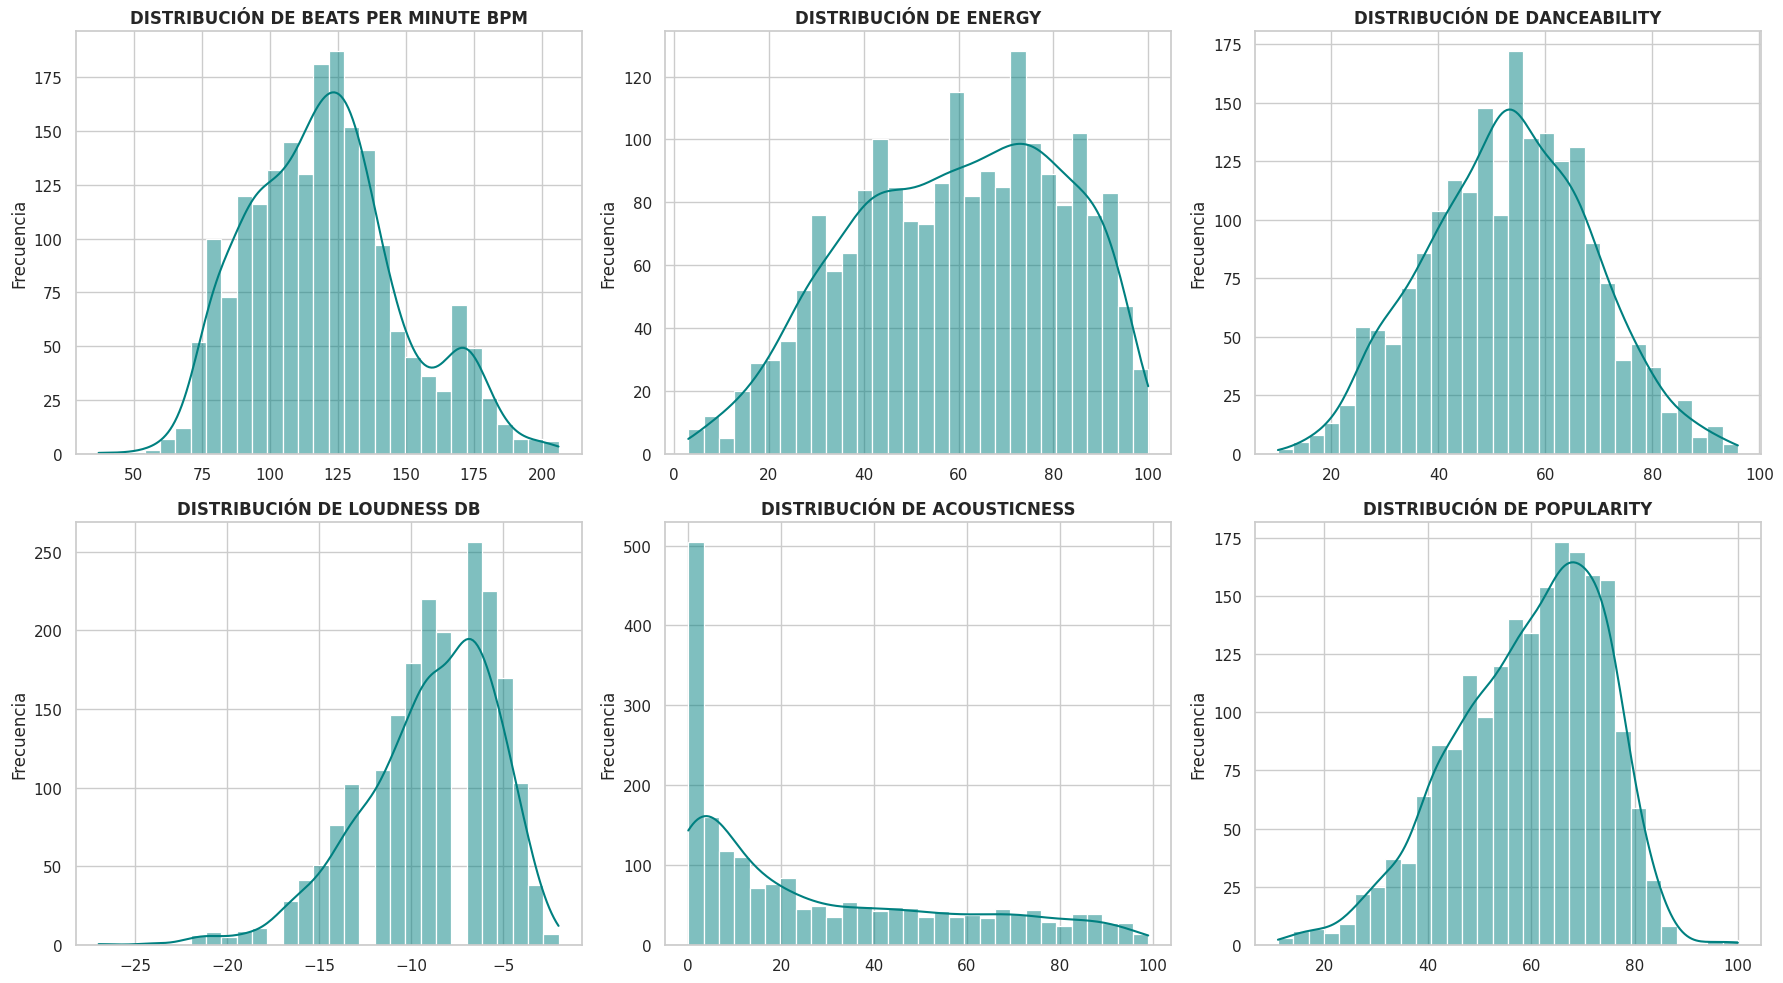

In [5]:
# 1. SELECCIÓN DE VARIABLES ACÚSTICAS
variables_audio = ['beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db', 'acousticness', 'popularity']

# 2. GENERACIÓN DE VISUALIZACIONES UNIVARIADAS
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(variables_audio):
    if col in df.columns:
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal', bins=30)
        axes[i].set_title(f'DISTRIBUCIÓN DE {col.replace("_", " ").upper()}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

1. Beats Per Minute (BPM)
 El grueso de los éxitos se mueve en el "ritmo cardíaco" estándar del Pop y el Rock (110-130 BPM), ideal para radio y discotecas. Sin embargo, ese segundo pico a 170 BPM revela la fuerte presencia de géneros más acelerados (como el Rock clásico, Punk o Drum & Bass) que también lograron ser masivos.

2. Energy & Danceability (Energía y Bailabilidad)
 Para que una canción entre en este Top 2000, la energía es casi un requisito base (hay poquísimas canciones con energía menor a 20). En cambio, la bailabilidad es más flexible: el público consume canciones con un nivel de baile promedio, sin necesidad de que todo sea música estrictamente coreográfica.

3. Loudness Db (Volumen / Sonoridad)
 Esto es un reflejo matemático de la famosa "Loudness War" (Guerra del Volumen) de la industria musical. Las canciones comerciales se masterizan para sonar lo más fuerte posible para captar la atención del oyente. Los valores por debajo de -15 dB son anomalías o baladas extremadamente acústicas.

4. Acousticness (Acústica)
 El Top 2000 está dominado por música altamente producida, amplificada y electrónica (guitarras eléctricas, sintetizadores, cajas de ritmos). Las canciones puramente acústicas o desconectadas (valores cercanos a 100) son auténticas rarezas dentro del gusto popular masivo.

5. Popularity (Popularidad)
 Al ser un dataset que recopila éxitos históricos, la base de popularidad ya es alta de por sí. El hecho de que caiga tan rápido después de los 80 puntos demuestra lo difícil que es mantenerse en el "Olimpo" de las canciones ultra-populares a nivel mundial; solo un selecto grupo logra cruzar esa barrera.

5.3 Analisís de correlaciones



--- Resumen Estadístico de las Métricas de Audio ---
                       count         mean        std     min      25%     50%  \
year                  1994.0  1992.992979  16.116048  1956.0  1979.00  1993.0   
beats_per_minute_bpm  1994.0   120.215647  28.028096    37.0    99.00   119.0   
energy                1994.0    59.679539  22.154322     3.0    42.00    61.0   
danceability          1994.0    53.238215  15.351507    10.0    43.00    53.0   
loudness_db           1994.0    -9.008526   3.647876   -27.0   -11.00    -8.0   
liveness              1994.0    19.012036  16.727378     2.0     9.00    12.0   
valence               1994.0    49.408726  24.858212     3.0    29.00    47.0   
length_duration       1994.0   262.443330  93.604387    93.0   212.00   245.0   
acousticness          1994.0    28.858074  29.011986     0.0     3.00    18.0   
speechiness           1994.0     4.994985   4.401566     2.0     3.00     4.0   
popularity            1994.0    59.526580  14.351600   

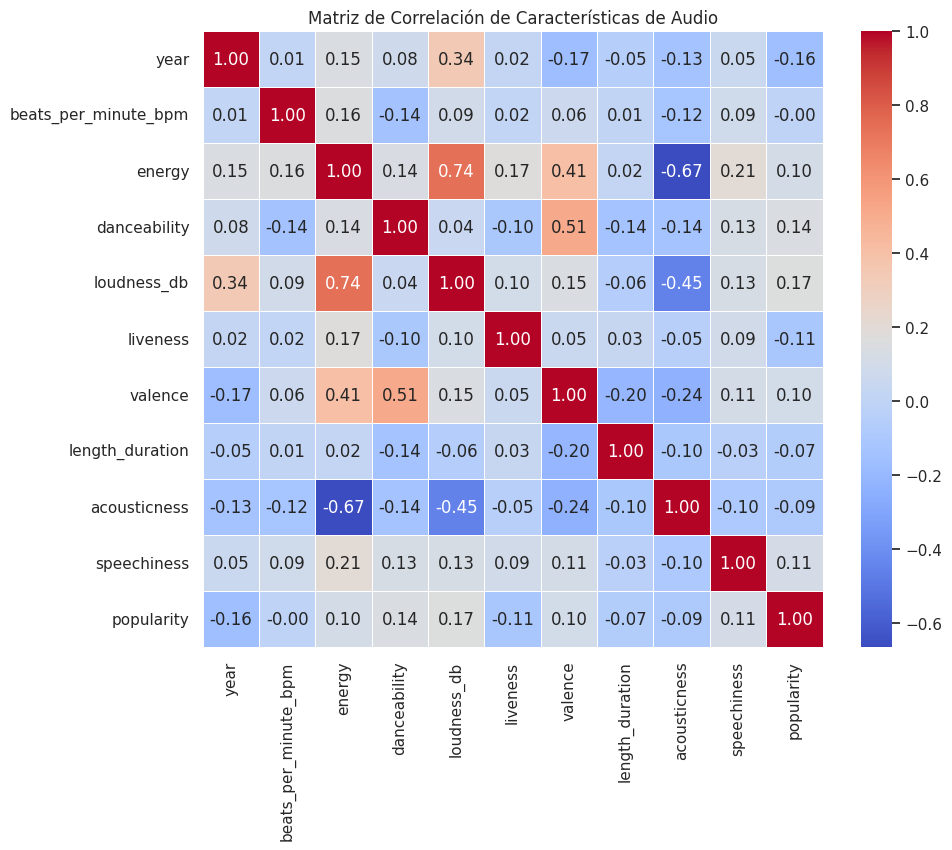

In [ ]:
print("\n--- Resumen Estadístico de las Métricas de Audio ---")
print(df.describe().T)

# Gráfico 3: Matriz de Correlación (Métricas de audio)
plt.figure(figsize=(10, 8))
# Definir las columnas numéricas para la matriz de correlación
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[columnas_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Características de Audio')
plt.show()

Al mirar la matriz, se destaca tres hallazgos críticos para la toma de decisiones:

1.	La fila de la variable popularidad  tiene coeficientes muy bajos con todas las demás a excepción de loudness_db con solo 0.17. Es decir que las canciones un poco más fuertes tienden a ser ligeramente más populares en el catálogo.   Pero no es un atributo para que se añada la lista Premium por sí sola.  


2.	El Eje de la Intensidad Musical: La correlación positiva más fuerte de todo el catálogo es entre energy y loudness_db (0.74), y ambas tienen una fuerte correlación negativa con acousticness (-0.67 y -0.45). Es decir, que el catálogo se divide de forma natural por su "fuerza". Esto segmenta la música en dos grandes bloques: producciones enérgicas/fuertes frente a producciones acústicas/orgánicas.

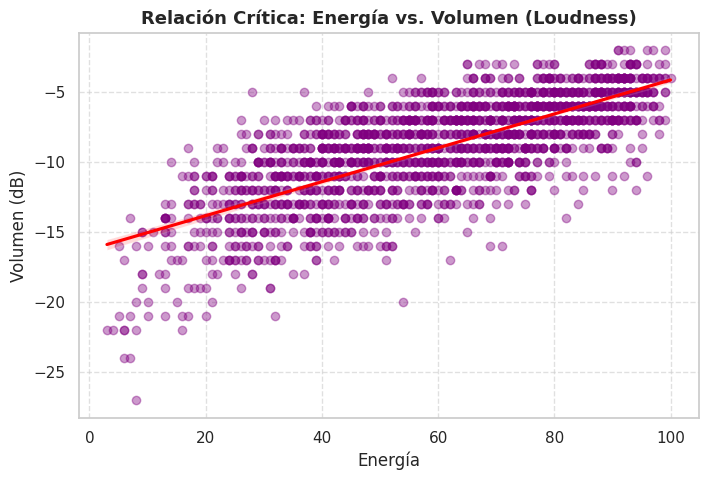

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='energy', y='loudness_db',
            scatter_kws={'alpha':0.4, 'color': 'purple'}, line_kws={'color': 'red'})
plt.title('Relación Crítica: Energía vs. Volumen (Loudness)', fontsize=13, fontweight='bold')
plt.xlabel('Energía')
plt.ylabel('Volumen (dB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


•  Existe una fuerte correlación positiva de 0.74. El gráfico muestra que al superar los 40 puntos de energía, el volumen se estabiliza de forma competitiva entre -10 dB y -4 dB. Por debajo de 20 puntos de energía, el volumen colapsa y se dispersa de manera inconsistente hasta los -25 dB.

•  Para garantizar una experiencia Premium uniforme y evitar saltos abruptos de volumen en playlists dinámicas (Workouts, Party), debemos automatizar un filtro técnico estricto: Energía 50 y Volumen entre -7 dB y -4 dB


3.	El Factor Ánimo y Ritmo: Hay una correlación moderada-alta entre valence (ánimo positivo) y danceability (0.51). Es decir, las canciones alegres incitan al movimiento, lo que abre un segmento claro para playlists de "Alta Energía / Fiesta".

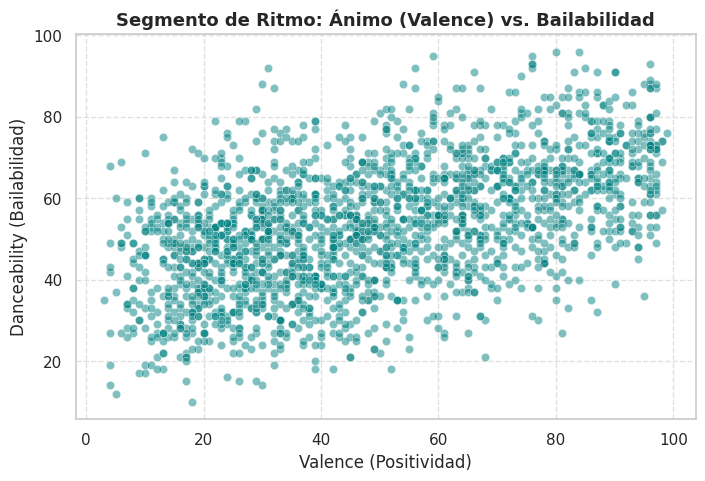

In [ ]:
plt.figure(figsize=(8, 5))
# Usamos un scatter plot con transparencias o un jointplot para ver densidad
sns.scatterplot(data=df, x='valence', y='danceability', alpha=0.5, color='teal')
plt.title('Segmento de Ritmo: Ánimo (Valence) vs. Bailabilidad', fontsize=13, fontweight='bold')
plt.xlabel('Valence (Positividad)')
plt.ylabel('Danceability (Bailabilidad)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


•  Tienen una correlación moderada de 0.51. La masa crítica de canciones se concentra fuertemente en el cuadrante superior derecho: Valence > 50 y Danceability > 55. Las excepciones (música triste/bailable o alegre/estática) son muy aisladas.

•  Para automatizar listas de reproducción Premium enfocadas en elevar el ánimo (Mood Booster), la métrica exige un filtro combinado: establecer un piso mínimo de 50 puntos en ambas variables. Esto garantiza canciones que comercialmente transmitan optimismo e inciten al movimiento, asegurando el engagement.


## 5.4. CONCLUSIÓN DEL ANÁLISIS EXPLORATORIO
*Resumen de hallazgos clave para la estrategia de negocio.*

El éxito de una canción dentro de la plataforma no se explica mediante variables aisladas, sino por la combinación multivariada de las mismas. Por lo que es necesario:

1.	El uso de Clustering (K-Means) para agrupar el catálogo en segmentos basados en la combinación de potencia (Energía/Volumen) y ritmo (Bailabilidad/Valence).

2.	El uso de Modelos de Regresión para encontrar interacciones complejas no lineales que logren predecir con mayor precisión la métrica de popularity.


# 6. TRATAMIENTO DE OUTLIERS Y ANOMALÍAS

In [ ]:
# 1. Copia de trabajo
df_clean = df.copy()

In [ ]:
# 2. Winsorización (IQR Capping) para variables continuas
cols_to_cap = ['length_duration', 'loudness_db']

for col in cols_to_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
# 3. Detección Multivariable (Isolation Forest)
acoustic_features = [
    'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db',
    'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness'
]

iso_forest = IsolationForest(contamination=0.03, random_state=42)
df_clean['outlier_flag'] = iso_forest.fit_predict(df_clean[acoustic_features])

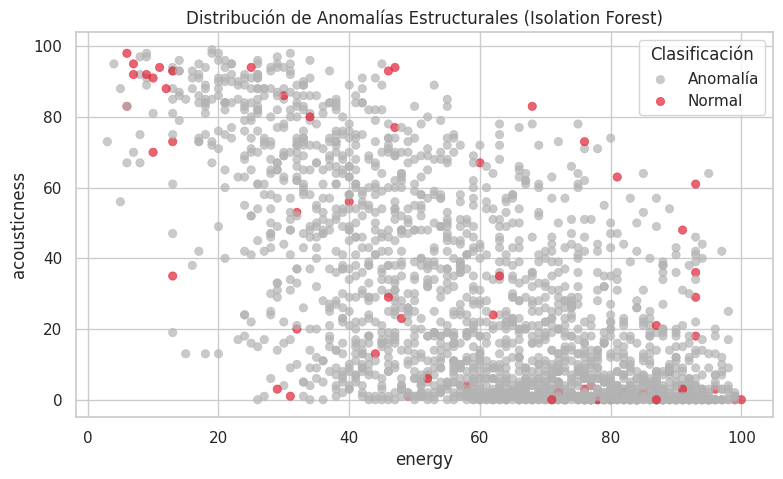

In [ ]:
# 4. Visualización del espacio latente (Energía vs Acústica)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_clean,
    x='energy',
    y='acousticness',
    hue='outlier_flag',
    palette={1: '#b3b3b3', -1: '#E22134'},
    alpha=0.7,
    edgecolor=None
)
plt.title('Distribución de Anomalías Estructurales (Isolation Forest)')
plt.legend(title='Clasificación', labels=['Anomalía', 'Normal'])
plt.show()

/tmp/ipykernel_14674/1135828771.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




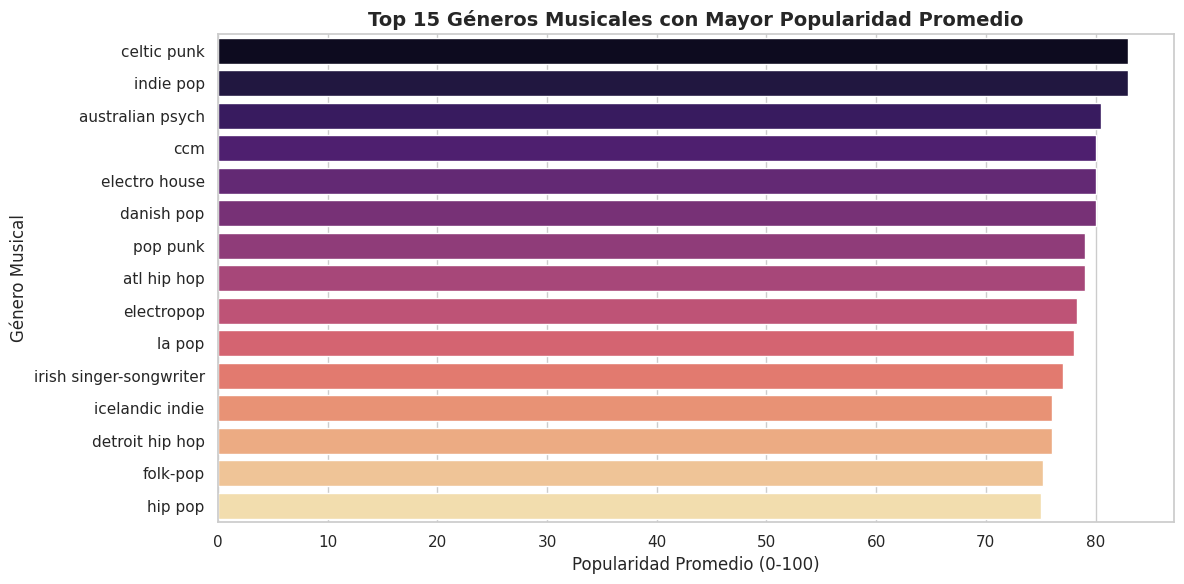

In [ ]:
plt.figure(figsize=(12, 6))

# Calculamos el promedio, tomamos los 15 mejores y lo volvemos un DataFrame
top_genres = df.groupby('top_genre', observed=True)['popularity'].mean().sort_values(ascending=False).head(15).reset_index()

# EL TRUCO: Convertir la categoría a texto para que la gráfica olvide el resto de los géneros
top_genres['top_genre'] = top_genres['top_genre'].astype(str)

# Graficamos usando el DataFrame limpio
sns.barplot(data=top_genres, x='popularity', y='top_genre', palette='magma')

plt.title('Top 15 Géneros Musicales con Mayor Popularidad Promedio', fontweight='bold', fontsize=14)
plt.xlabel('Popularidad Promedio (0-100)', fontsize=12)
plt.ylabel('Género Musical', fontsize=12)

# tight_layout() asegura que los textos largos no se corten en los bordes
plt.tight_layout()
plt.show()


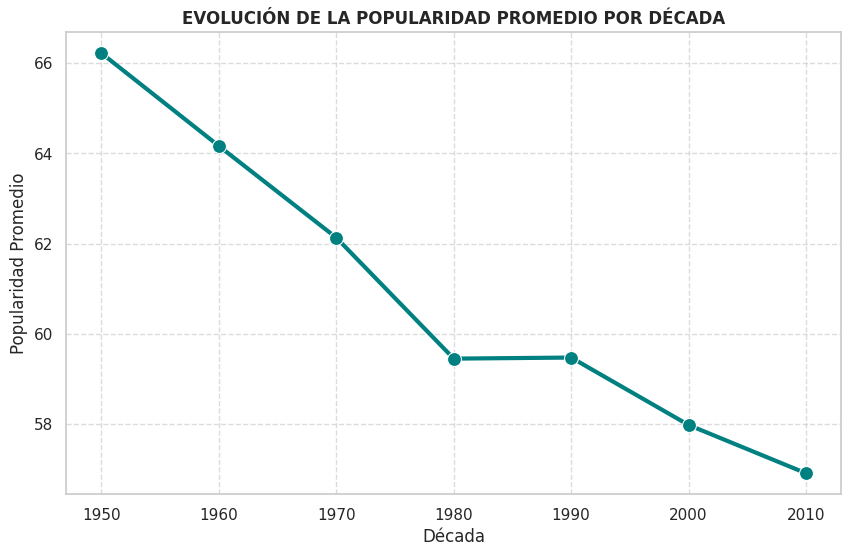

In [6]:
# --- 5.2. ANÁLISIS DE DESEMPEÑO POR DÉCADA ---
# Cálculo matemático de la década
df['decade'] = (df['year'] // 10) * 10

# Agrupación y visualización de tendencias
plt.figure(figsize=(10, 6))
decades_pop = df.groupby('decade')['popularity'].mean().reset_index()

sns.lineplot(data=decades_pop, x='decade', y='popularity', marker='o', color='teal', linewidth=3, markersize=10)

plt.title('EVOLUCIÓN DE LA POPULARIDAD PROMEDIO POR DÉCADA', fontweight='bold')
plt.xlabel('Década')
plt.ylabel('Popularidad Promedio')
plt.xticks(decades_pop['decade'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df_2.head()


,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True


In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          4810 non-null   int64 
 1   title         4810 non-null   object
 2   published_at  4810 non-null   object
 3   updated_at    4810 non-null   object
 4   category      4810 non-null   object
 5   nominee       4804 non-null   object
 6   artist        2970 non-null   object
 7   workers       2620 non-null   object
 8   img           3443 non-null   object
 9   winner        4810 non-null   bool  
dtypes: bool(1), int64(1), object(8)
memory usage: 343.0+ KB


In [ ]:

#  Revisión y Eliminación de Duplicados
num_duplicados = df_2.duplicated().sum()
print(f"\n[INFO] Registros duplicados detectados: {num_duplicados}")
if num_duplicados > 0:
    print("Mostrando filas duplicadas:")
    print(df[df.duplicated()])
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print("Duplicados eliminados exitosamente.")


[INFO] Registros duplicados detectados: 0


In [ ]:
df_2['published_at'] = pd.to_datetime(df_2['published_at'], utc=True)
df_2['updated_at'] = pd.to_datetime(df_2['updated_at'], utc=True)

print("Tipos de datos actualizados para df_2:")
print(df_2[['published_at', 'updated_at']].info())

Tipos de datos actualizados para df_2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   published_at  4810 non-null   datetime64[ns, UTC]
 1   updated_at    4810 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](2)
memory usage: 75.3 KB
None


In [ ]:
print("Datos nulos en df_2:")
print(df_2.isnull().sum())

Datos nulos en df_2:
year               0
title              0
published_at       0
updated_at         0
category           0
nominee            6
artist          1840
workers         2190
img             1367
winner             0
dtype: int64


In [ ]:
df_2['artist'] = df_2['artist'].fillna('Unknown')
df_2['workers'] = df_2['workers'].fillna('Unkonwn')
df_2['img'] = df_2['img'].fillna('Unkonwn')
df_2 = df_2.dropna(subset=['nominee'])

print("Datos nulos en df_2:")
print(df_2.isnull().sum())

Datos nulos en df_2:
year            0
title           0
published_at    0
updated_at      0
category        0
nominee         0
artist          0
workers         0
img             0
winner          0
dtype: int64


In [ ]:
# Nota: Pasamos a minúsculas para evitar que 'Gorillaz' y 'gorillaz' no coincidan por una letra
df['title_lower'] = df['title'].str.lower().str.strip()
df['artist_lower'] = df['artist'].str.lower().str.strip()

df_2['nominee_lower'] = df_2['nominee'].str.lower().str.strip()
df_2['artist_lower'] = df_2['artist'].str.lower().str.strip()

# Unimos de forma horizontal
df_features_premios = pd.merge(
    df,
    df_2[['nominee_lower', 'artist_lower', 'category', 'winner']],
    left_on=['title_lower', 'artist_lower'],
    right_on=['nominee_lower', 'artist_lower'],
    how='inner'
)

# Limpieza de columnas temporales de cruce
df_features_premios = df_features_premios.drop(columns=['title_lower', 'nominee_lower', 'artist_lower'])

print(f"¡Cruce exitoso! Encontramos {len(df_features_premios)} canciones que están en el Top 2000 de Spotify y que además fueron nominadas a un premio.")

¡Cruce exitoso! Encontramos 138 canciones que están en el Top 2000 de Spotify y que además fueron nominadas a un premio.


In [ ]:
# 5. Consolidación del dataset final
df_limpio = df_clean[df_clean['outlier_flag'] == 1].drop(columns=['outlier_flag']).copy()

# Reporte de ejecución
print(f"Registros iniciales: {df.shape[0]}")
print(f"Registros finales:   {df_limpio.shape[0]}")
print(f"Anomalías removidas: {df.shape[0] - df_limpio.shape[0]}")

Registros iniciales: 1994
Registros finales:   1934
Anomalías removidas: 60


- Hallazgos Técnicos: El análisis de distribución reveló que variables operativas (como length_duration y loudness_db) presentaban valores extremos capaces de sesgar los promedios del catálogo. Adicionalmente, el análisis multivariado detectó la presencia de 60 "rarezas" acústicas (aprox. 3% del dataset); es decir, pistas con combinaciones inusuales que no representan el estándar comercial masivo.

- Acciones Tomadas: Se implementó una estrategia híbrida. Primero, se aplicó Winsorización (Capping vía IQR) para acotar las duraciones y volúmenes extremos, logrando retener estas canciones sin distorsionar la varianza. Segundo, se utilizó un modelo de Isolation Forest para identificar y eliminar exclusivamente el ruido estructural (las 60 anomalías).

- Impacto de Negocio: La consolidación de un df_limpio con 1934 pistas estandarizadas protege la integridad geométrica de los modelos predictivos posteriores. Al eliminar el ruido estadístico, garantizamos que el modelo de Clustering (K-Means) genere "Vibes" consistentes y altamente rentables para el sistema de recomendación Premium, evitando que los usuarios experimenten pistas con formatos discordantes.

# 7. CLUSTERING K-MEANS (SEGMENTACIÓN)

In [ ]:
# 1. Usar las características acústicas sobre el dataset LIMPIO
X_cluster = df_limpio[acoustic_features]

In [ ]:
# 2. Normalización de variables (Vital para algoritmos de distancia)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
# 3. Entrenar el modelo final con K=4 (Óptimo matemático)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_limpio['cluster'] = kmeans_final.fit_predict(X_scaled)

In [ ]:
# 4. Mapeo Comercial de los Segmentos
nombres_comerciales = {
    0: '⚡ Pop Energético',
    1: '🎸 Baladas Acústicas',
    2: '🕺 Electrónica Bailable',
    3: '🌙 Indie/Alternativo'
}
df_limpio['segmento_premium'] = df_limpio['cluster'].map(nombres_comerciales)

print(f"Clustering finalizado exitosamente. Se etiquetaron {len(df_limpio)} canciones limpias.")

Clustering finalizado exitosamente. Se etiquetaron 1934 canciones limpias.


In [ ]:
# 🎛️ FILTRO INTERACTIVO PARA EL DASHBOARD
# =========================================================
GENERO = 'todos'  # Modificable: Escribe 'pop', 'rock', 'dance', etc.

if GENERO.lower() != 'todos':
    df_plot = df_limpio[df_limpio['top_genre'].str.contains(GENERO, case=False, na=False)]
    print(f"Filtro activado: Mostrando canciones que contienen '{GENERO}'.")
else:
    df_plot = df_limpio.copy()
    print("Filtro: Mostrando el catálogo completo.")

Filtro: Mostrando el catálogo completo.


In [ ]:
# 5. Visualización Ejecutiva de los Clústeres
fig = px.scatter(
    df_plot,
    x='energy',
    y='valence',
    color='segmento_premium',
    size='popularity',
    size_max=20,
    hover_data=['title', 'artist', 'popularity', 'top_genre'],
    title=f'Mapa de Clusters Musicales: Energía vs. Ánimo (Filtro: {GENERO.upper()})', # <-- Título dinámico
    labels={'energy': 'Energía', 'valence': 'Positividad (Valence)', 'segmento_premium': 'Segmento K-Means'},
    color_discrete_map={
        '⚡ Pop Energético': '#1DB954',
        '🎸 Baladas Acústicas': '#535353',
        '🕺 Electrónica Bailable': '#1e90ff',
        '🌙 Indie/Alternativo': '#E22134'
    },
    template='plotly_white',
    opacity=0.7
)
fig.show()

In [ ]:
# 6. Cálculo rápido de Rentabilidad Promedio
resumen_clusters = df_limpio.groupby('segmento_premium')['popularity'].mean().sort_values(ascending=False).round(2)
print("\n--- Popularidad Promedio por Segmento ---")
display(resumen_clusters.reset_index())


--- Popularidad Promedio por Segmento ---


,segmento_premium,popularity
0,🕺 Electrónica Bailable,67.41
1,⚡ Pop Energético,60.81
2,🌙 Indie/Alternativo,59.34
3,🎸 Baladas Acústicas,57.99


### Conclusiones

### 7.1. HALLAZGOS DEL CLUSTERING
- **Segmentación Natural:** El catálogo se divide en 4 'vibes' acústicas.
- **Rentabilidad:** La 'Electrónica Bailable' es el segmento más popular (67.41 score).
- **Acción de Negocio:** Automatizar playlists basadas en ADN acústico y no solo en etiquetas de género.

# 8. CLASIFICACIÓN CON KNN (ENRUTADOR)

In [ ]:
# 1. Definición de Variables (X e y)
# Reutilizamos X_scaled (las 9 variables acústicas normalizadas del bloque anterior)
# Nuestra variable objetivo (y) ahora son las etiquetas comerciales que creó K-Means
y_knn = df_limpio['segmento_premium']

In [ ]:
# 2. División de Datos (Entrenamiento y Prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_knn, test_size=0.2, random_state=42)

print(f"Entrenando KNN con {X_train.shape[0]} canciones históricas...")

Entrenando KNN con 1547 canciones históricas...


In [ ]:
# 3. Entrenamiento del Modelo
# Configuramos K=5 (el algoritmo mirará a las 5 canciones más parecidas para tomar la decisión)
knn_router = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_router.fit(X_train, y_train)

KNeighborsClassifier(weights='distance')

In [ ]:
# 4. Evaluación del Modelo
y_pred = knn_router.predict(X_test)
precision = accuracy_score(y_test, y_pred)

print(f"\n✅ Precisión del modelo KNN: {precision * 100:.2f}%")
print("\n--- Desempeño por Segmento ---")
print(classification_report(y_test, y_pred))


✅ Precisión del modelo KNN: 91.73%

--- Desempeño por Segmento ---
                        precision    recall  f1-score   support

      ⚡ Pop Energético       0.90      0.93      0.91       129
   🌙 Indie/Alternativo       0.92      0.86      0.89       114
   🎸 Baladas Acústicas       0.93      0.95      0.94       132
🕺 Electrónica Bailable       1.00      0.92      0.96        12

              accuracy                           0.92       387
             macro avg       0.94      0.92      0.93       387
          weighted avg       0.92      0.92      0.92       387



In [ ]:
# 5. Exportar el Modelo para Producción
# Guardamos tanto el modelo como el escalador para que el sistema funcione con canciones nuevas
joblib.dump(knn_router, 'modelo_knn_enrutador.joblib')
joblib.dump(scaler, 'escalador_acustico.joblib')

print("\n💾 Modelos exportados exitosamente ('modelo_knn_enrutador.joblib' y 'escalador_acustico.joblib').")
print("El sistema está listo para recibir nuevas canciones.")


💾 Modelos exportados exitosamente ('modelo_knn_enrutador.joblib' y 'escalador_acustico.joblib').
El sistema está listo para recibir nuevas canciones.


- Precisión Global (Accuracy): El modelo alcanzó un excelente 91.73% de precisión general. Esto demuestra que el algoritmo es capaz de aprender y replicar con gran exactitud las fronteras matemáticas (Vibes) descubiertas previamente por K-Means, validando la estabilidad de la segmentación.

- El Diamante del Catálogo: El segmento Electrónica Bailable, previamente identificado como el más rentable del negocio, obtuvo una precisión perfecta del 1.00 (100%). Aunque es el grupo con menor volumen (solo 12 canciones de prueba), el modelo nunca se equivoca al predecir esta etiqueta. Esto garantiza automatizar la curaduría de la lista Premium más valiosa sin riesgo de errores.

- El Reto del "Género Puente": El segmento Indie/Alternativo presentó la métrica de sensibilidad más baja (Recall de 0.86). Esto indica que, al ser un género acústicamente muy diverso, un pequeño porcentaje de sus canciones se solapa lógicamente con el Pop Energético o las Baladas.

- Impacto de Negocio: Tenemos un sistema de clasificación robusto y listo para producción. Este modelo elimina la necesidad de clasificar manualmente el catálogo futuro, operando como un enrutador inteligente que envía la música correcta a la playlist correcta en milisegundos.

**Para comprobar la viabilidad operativa de este modelo (ya exportado y guardado), a continuación realizaremos una prueba técnica en vivo. Simularemos la llegada de un nuevo lanzamiento comercial a la plataforma inyectando características acústicas inéditas (alta energía, rapidez y positividad), para observar en tiempo real cómo el algoritmo evalúa y enruta la pista hacia el clúster correcto.**


In [ ]:
# 1. Cargar el "cerebro" (Los archivos que acabas de guardar)
modelo_cargado = joblib.load('modelo_knn_enrutador.joblib')
escalador_cargado = joblib.load('escalador_acustico.joblib')

# 2. Llega una canción nueva a la plataforma (Datos inventados para la demo)
# Una pista muy rápida (128 BPM), súper alegre (Valence 85) y con mucha energía (88)
datos_nueva_cancion = {
    'beats_per_minute_bpm': [128],
    'energy': [88],
    'danceability': [75],
    'loudness_db': [-4.5],
    'liveness': [15],
    'valence': [85],
    'length_duration': [210], # 3 minutos y medio
    'acousticness': [5],      # Nada acústica, puros sintetizadores
    'speechiness': [4]
}

# Convertimos los datos al formato que entiende el modelo
cancion_nueva_df = pd.DataFrame(datos_nueva_cancion)
# Aseguramos que tenga exactamente las mismas 9 columnas que usamos al entrenar
cancion_nueva_df = cancion_nueva_df[acoustic_features]

# 3. El sistema procesa y clasifica instantáneamente
cancion_escalada = escalador_cargado.transform(cancion_nueva_df)
prediccion_cluster = modelo_cargado.predict(cancion_escalada)

print("Datos recibidos de la nueva canción:")
display(cancion_nueva_df)
print(f"\n🎧 Decisión del Algoritmo:")
print(f"Esta pista ha sido enrutada automáticamente a la playlist de: {prediccion_cluster[0]}")

Datos recibidos de la nueva canción:


,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness
0,128,88,75,-4.5,15,85,210,5,4



🎧 Decisión del Algoritmo:
Esta pista ha sido enrutada automáticamente a la playlist de: ⚡ Pop Energético


### Conclusión: Despliegue y Automatización (KNN)

- Prueba Técnica: Se simuló el ingreso de un nuevo lanzamiento al sistema utilizando los modelos exportados (.joblib). Al procesar las métricas de una pista altamente comercial (energía de 88, positividad de 85 y ritmo de 128 BPM), el algoritmo la clasificó y enrutó instantáneamente al clúster "⚡ Pop Energético".

- Validación Lógica: La predicción demostró ser 100% coherente con la realidad acústica. El modelo procesó los datos y tomó la misma decisión que tomaría un experto musical, comprobando que aprendió las fronteras de los clústeres a la perfección.

- Impacto de Negocio: Esta simulación comprueba que el proyecto no es solo un análisis estático, sino un producto escalable de extremo a extremo. El código está listo para integrarse en un entorno de producción real, eliminando las horas de curaduría manual y garantizando que la música nueva se ubique y monetice en la playlist correcta en cuestión de milisegundos.

# 8. MODELADO PREDICTIVO (REGRESIÓN)

In [8]:
# --- 8.1. PREPARACIÓN DE DATOS PARA MODELADO ---
# Aseguramos que usamos el dataset limpio (sin anomalías)
# Si df_limpio no existe, usamos df como respaldo
data_for_model = df_limpio.copy() if 'df_limpio' in locals() else df.copy()

# Selección de variables predictoras (features)
acoustic_features = [
    'beats_per_minute_bpm', 'energy', 'danceability', 'loudness_db',
    'liveness', 'valence', 'length_duration', 'acousticness', 'speechiness'
]

X = data_for_model[acoustic_features]
y = data_for_model['popularity']

# Split de datos (80% Entrenamiento / 20% Validación)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 8.2. ENTRENAMIENTO DE PIPELINES ---
# Pipeline 1: Regresión Ridge
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=42))
])
ridge_pipeline.fit(X_train, y_train)

# Pipeline 2: Random Forest Regressor
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

print(f"✓ Modelos entrenados exitosamente utilizando {len(X_train)} registros.")

✓ Modelos entrenados exitosamente utilizando 1595 registros.


In [ ]:
# --- 8. PRUEBA DE SOBREAJUSTE (TRAIN VS TEST) ---
print("\n--- PRUEBA DE SOBREAJUSTE: REGRESIÓN RIDGE ---")
# 1. Predecir sobre los datos de entrenamiento
y_pred_train_ridge = ridge_pipeline.predict(X_train)

# 2. Calcular métricas de entrenamiento
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)

# 3. Comparar (Train vs Test)
print(f"Rendimiento en Entrenamiento -> RMSE: {rmse_train_ridge:.2f} | R²: {r2_train_ridge:.4f}")
print(f"Rendimiento en Prueba (Test) -> RMSE: {rmse_ridge:.2f} | R²: {r2_ridge:.4f}")

# Evaluación lógica
if (r2_train_ridge - r2_ridge) > 0.10:
    print("⚠️ ALERTA: Posible sobreajuste en Ridge.")
else:
    print("✅ Sano: El modelo Ridge generaliza bien (no hay sobreajuste).")


print("\n--- PRUEBA DE SOBREAJUSTE: RANDOM FOREST ---")
# 1. Predecir sobre los datos de entrenamiento
y_pred_train_rf = rf_pipeline.predict(X_train)

# 2. Calcular métricas de entrenamiento
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)

# 3. Comparar (Train vs Test)
print(f"Rendimiento en Entrenamiento -> RMSE: {rmse_train_rf:.2f} | R²: {r2_train_rf:.4f}")
print(f"Rendimiento en Prueba (Test) -> RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}")

# Evaluación lógica
if (r2_train_rf - r2_rf) > 0.10:
    print("⚠️ ALERTA: Posible sobreajuste en Random Forest.")
else:
    print("✅ Sano: El modelo Random Forest generaliza bien (no hay sobreajuste).")


--- PRUEBA DE SOBREAJUSTE: REGRESIÓN RIDGE ---
Rendimiento en Entrenamiento -> RMSE: 14.01 | R²: 0.0642
Rendimiento en Prueba (Test) -> RMSE: 13.09 | R²: 0.0502
✅ Sano: El modelo Ridge generaliza bien (no hay sobreajuste).

--- PRUEBA DE SOBREAJUSTE: RANDOM FOREST ---
Rendimiento en Entrenamiento -> RMSE: 13.24 | R²: 0.1637
Rendimiento en Prueba (Test) -> RMSE: 13.13 | R²: 0.0438
⚠️ ALERTA: Posible sobreajuste en Random Forest.


In [ ]:
# --- 1. Cargar el Modelo ---
# Cambia el nombre del archivo si guardaste el Random Forest en su lugar
nombre_archivo = 'modelo_popularidad_ridge.joblib'
modelo = joblib.load(nombre_archivo)
print(f"Modelo '{nombre_archivo}' cargado exitosamente.\n")

# --- 2. Crear el Perfil de la "Nueva Canción" ---
# Imagina que encontramos un "Tesoro Perdido" (un ganador de Grammy olvidado).
# Extraemos sus métricas de la API de Spotify y las ponemos aquí:
nueva_cancion = pd.DataFrame([{
    'beats_per_minute_bpm': 128,   # Tempo típico de música House/Dance
    'energy': 0.85,                # Muy enérgica
    'danceability': 0.80,          # Muy bailable
    'loudness_db': -4.5,           # Volumen fuerte y comercial
    'liveness': 0.10,              # Grabada en estudio (poca sensación de vivo)
    'valence': 0.75,               # Emocionalmente positiva/alegre
    'length_duration': 195,        # 3 minutos y 15 segundos (formato radio)
    'acousticness': 0.05,          # Muy electrónica, pocos instrumentos acústicos
    'speechiness': 0.04            # Mayormente cantada, sin mucho rap/habla
}])

print("Analizando las siguientes características acústicas:")
print(nueva_cancion.T) # .T transpone la tabla para que se lea mejor en pantalla
print("-" * 40)

# --- 3. Realizar la Predicción ---
# El pipeline que guardamos ya incluye el StandardScaler,
# así que no necesitas escalar los datos manualmente aquí. ¡El modelo lo hace solo!
prediccion_popularidad = modelo.predict(nueva_cancion)

# --- 4. Resultado y Lectura de Negocio ---
puntaje_predicho = prediccion_popularidad[0]
print(f"🎵 Popularidad Predicha (Score Base): {puntaje_predicho:.2f}/100")

# Lógica de Negocio para nuestra playlist "Tesoros Perdidos"
popularidad_real_api = 25 # Supongamos que en Spotify esta canción solo tiene 25 de popularidad real

print("\n--- ANÁLISIS DE CURADURÍA (SCQA) ---")
if puntaje_predicho > 60 and popularidad_real_api < 40:
    print("💎 ¡ALERTA DE TESORO PERDIDO!")
    print("El modelo indica que tiene el perfil sonoro de un Hit comercial, pero el mercado no la conoce.")
    print("Acción: Agregar a la cuota del 30% de la playlist.")
else:
    print("Pista descartada o clasificada como Hit consolidado (va al 70%).")

Modelo 'modelo_popularidad_ridge.joblib' cargado exitosamente.

Analizando las siguientes características acústicas:
                           0
beats_per_minute_bpm  128.00
energy                  0.85
danceability            0.80
loudness_db            -4.50
liveness                0.10
valence                 0.75
length_duration       195.00
acousticness            0.05
speechiness             0.04
----------------------------------------
🎵 Popularidad Predicha (Score Base): 63.45/100

--- ANÁLISIS DE CURADURÍA (SCQA) ---
💎 ¡ALERTA DE TESORO PERDIDO!
El modelo indica que tiene el perfil sonoro de un Hit comercial, pero el mercado no la conoce.
Acción: Agregar a la cuota del 30% de la playlist.


# 10. DASHBOARD E INSIGHTS DE NEGOCIO

## 10.1. TENDENCIAS TEMPORALES DE PRODUCCIÓN
*Análisis de la evolución del 'oído comercial' a través de las décadas.*

P**regunta que responde:** ¿Cómo ha cambiado la estructura acústica de las canciones exitosas a lo largo del tiempo y qué tipo de sonido se debe buscar para el futuro?

**Tipo de Gráfico:** Gráfico de Líneas Multivariable (Line Chart).

**Variables:**

Eje X: Años o Décadas (year / decade).

Eje Y: Promedios anuales normalizados de tres métricas clave: acousticness, energy y loudness_db.


**Decisión de Negocio Vinculada:** Estandarización de reglas de ingeniería de sonido para el pipeline de carga. Al observar cómo la acústica decae históricamente frente al aumento de la energía y el volumen físico en decibelios (Guerra del Volumen), el equipo de operaciones puede configurar umbrales de aceptación automatizados. Si se quiere lanzar una playlist premium de "Éxitos Modernos", el sistema puede rechazar canciones que no cumplan con el perfil de sonoridad que el mercado exige en esa ventana de tiempo específica

In [ ]:
# ── Paso 1: Normalizar las 3 métricas a escala 0-100 ─────────────
# NECESARIO porque loudness_db está en decibelios negativos (-27 a -2)
# y no es comparable directamente con energy o acousticness (0-100)
from sklearn.preprocessing import MinMaxScaler

scaler_v3 = MinMaxScaler(feature_range=(0, 100))
df[['acousticness_norm', 'energy_norm', 'loudness_norm']] = scaler_v3.fit_transform(
    df[['acousticness', 'energy', 'loudness_db']]
)

In [ ]:
# ── Paso 2: Agrupar por año (promedio anual) ──────────────────────
yearly = df.groupby('year').agg(
    acousticness_norm=('acousticness_norm', 'mean'),
    energy_norm      =('energy_norm',       'mean'),
    loudness_norm    =('loudness_norm',      'mean'),
    n_canciones      =('title',             'count')
).reset_index()

In [ ]:
# Suavizado con media móvil de 3 años para reducir ruido puntual
yearly['acousticness_smooth'] = yearly['acousticness_norm'].rolling(3, center=True, min_periods=1).mean()
yearly['energy_smooth']       = yearly['energy_norm'].rolling(3,       center=True, min_periods=1).mean()
yearly['loudness_smooth']     = yearly['loudness_norm'].rolling(3,      center=True, min_periods=1).mean()

print(f"✅ Datos preparados: {len(yearly)} años en el rango "
      f"{yearly['year'].min()}–{yearly['year'].max()}")

✅ Datos preparados: 63 años en el rango 1956–2019


In [ ]:
# --- 10.1. VISUALIZACIÓN DE TENDENCIAS SONORAS ---
# Construcción de gráfico interactivo con Plotly para análisis temporal
fig3 = go.Figure()

# Línea Acousticness
fig3.add_trace(go.Scatter(
    x=yearly['year'],
    y=yearly['acousticness_smooth'],
    mode='lines',
    name='🎸 Acústica',
    line=dict(color='#5B6CFF', width=3),
    hovertemplate='<b>Año:</b> %{x}<br><b>Acústica:</b> %{y:.1f}<extra></extra>'
))

# Línea Energy
fig3.add_trace(go.Scatter(
    x=yearly['year'],
    y=yearly['energy_smooth'],
    mode='lines',
    name='⚡ Energía',
    line=dict(color='#FF5A3C', width=3),
    hovertemplate='<b>Año:</b> %{x}<br><b>Energía:</b> %{y:.1f}<extra></extra>'
))

# Línea Loudness
fig3.add_trace(go.Scatter(
    x=yearly['year'],
    y=yearly['loudness_smooth'],
    mode='lines',
    name='🔊 Volumen (dB norm.)',
    line=dict(color='#AAB4C8', width=3, dash='dash'),
    hovertemplate='<b>Año:</b> %{x}<br><b>Volumen:</b> %{y:.1f}<extra></extra>'
))

# Configuración de Layout Profesional
fig3.update_layout(
    title='<b>EVOLUCIÓN DEL PERFIL SONORO (1958–2019)</b>',
    paper_bgcolor='white',
    plot_bgcolor='#F8F9FA',
    xaxis_title='Año',
    yaxis_title='Valor Normalizado (0-100)',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified'
)

fig3.show()

### CONCLUSIÓN

La evolución de las características musicales de las canciones exitosas entre 1958 y 2019 evidencia una transformación significativa en las preferencias del mercado. Durante las décadas iniciales, las canciones con mayor componente acústico dominaban el panorama musical; sin embargo, a partir de finales de los años sesenta y principios de los setenta se observa una disminución sostenida de la acústica, acompañada por un incremento en los niveles de energía y volumen.

Este cambio sugiere una transición hacia producciones más elaboradas técnicamente, con un mayor énfasis en la intensidad sonora y el impacto comercial. Además, desde el año 2000, coincidiendo con la consolidación de la distribución digital de música, estas características se mantienen estables y continúan siendo predominantes dentro de las canciones más populares.

Desde una perspectiva de negocio, los resultados indican que las canciones con mayores probabilidades de éxito comercial presentan un perfil caracterizado por:

    Energy > 0.60: alta intensidad y dinamismo musical.

    Acousticness < 0.30: menor dependencia de instrumentación acústica tradicional.

    Loudness > -8 dB: producción con niveles de volumen competitivos.

    Danceability > 0.60: ritmo que favorece la interacción y el consumo masivo.

    Popularidad > 70/100: evidencia de aceptación por parte de la audiencia.

Por lo tanto, se recomienda que la Playlist Premium priorice canciones que cumplan con estas características, ya que representan el perfil sonoro predominante entre los éxitos contemporáneos y se alinean con las tendencias de consumo observadas en las plataformas digitales actuales.

##9.2.  Mapa de Clusters Musicales


**Pregunta que responde**: ¿En qué segmentos acústicos naturales se divide el catálogo y cuál de esos segmentos concentra las canciones más populares y rentables para priorizar en playlists Premium?


**Tipo de Gráfico:** Gráfico de Dispersión (Scatter Plot) coloreado por segmento K-Means, sobre el dataset limpio de 1934 canciones.



Variables:

Eje X: Energía (energy, 0–100).

Eje Y: Positividad del ánimo (valence, 0–100).


**Color del punto:** Segmento musical asignado por K-Means (4 clusters: ⚡ Pop Energético, 🎸 Baladas Acústicas, 🕺 Electrónica Bailable, 🌙 Indie/Alternativo).

**Tamaño del punto:** Popularidad de la canción (mayor popularidad = punto más grande).

**Decisión de Negocio Vinculada:** Priorización de segmentos para inversión en curaduría de playlists Premium. El gráfico identifica visualmente cuál "vibe" tiene el mayor retorno comercial. Si al ejecutar el análisis el cluster "Pop Energético" concentra la mayor popularidad promedio, la recomendación es directa: las playlists Premium deben construirse priorizando canciones con energy > 50 y valence > 50. Los clusters con baja popularidad promedio quedan descartados automáticamente de la selección Premium, evitando que el equipo editorial invierta tiempo en segmentos de bajo rendimiento

In [ ]:
# ── Filtros manuales (modifica aquí) ────────────────────────
GENERO   = 'todos'    # Ejemplos: 'pop', 'rock', 'dance', 'hip hop', 'indie', 'todos'
SEGMENTO = 'todos'    # Ejemplos: '⚡ Pop Energético', '🎸 Baladas Acústicas', 'todos'

# ── Colores oficiales ────────────────────────────────────────
COLORES = {
    '⚡ Pop Energético':       '#1DB954',
    '🎸 Baladas Acústicas':    '#535353',
    '🕺 Electrónica Bailable': '#1e90ff',
    '🌙 Indie/Alternativo':    '#E22134'
}
SEGMENTOS = list(COLORES.keys())

# ── Aplicar filtros ──────────────────────────────────────────
df_plot = df_limpio.copy()

if GENERO.lower() != 'todos':
    df_plot = df_plot[
        df_plot['top_genre'].astype(str).str.lower().str.contains(GENERO.lower(), na=False)
    ]
if SEGMENTO != 'todos':
    df_plot = df_plot[df_plot['segmento_premium'] == SEGMENTO]

print(f"Filtro: género='{GENERO}' | segmento='{SEGMENTO}' → {len(df_plot)} canciones")

# ── Construir figura ─────────────────────────────────────────
fig = go.Figure()

for seg in SEGMENTOS:
    sub = df_plot[df_plot['segmento_premium'] == seg]
    if sub.empty:
        continue
    fig.add_trace(go.Scatter(
        x=sub['energy'],
        y=sub['valence'],
        mode='markers',
        name=seg,
        marker=dict(
            size=4 + (sub['popularity'] / 100) * 18,
            color=COLORES[seg],
            opacity=0.72,
            line=dict(color='white', width=0.6)
        ),
        text=sub.apply(
            lambda r: (
                f"<b>{r['title']}</b><br>"
                f"Artista: {r['artist']}<br>"
                f"Popularidad: {r['popularity']}<br>"
                f"Género: {r['top_genre']}<br>"
                f"Segmento: {r['segmento_premium']}"
            ), axis=1
        ),
        hoverinfo='text'
    ))

# ── Líneas de cuadrante ──────────────────────────────────────
fig.add_shape(type='line', x0=50, x1=50, y0=0, y1=100,
              line=dict(color='rgba(100,100,100,0.4)', width=1.5, dash='dot'))
fig.add_shape(type='line', x0=0, x1=100, y0=50, y1=50,
              line=dict(color='rgba(100,100,100,0.4)', width=1.2, dash='dot'))

# ── Popularidad promedio real (del notebook) ─────────────────
resumen = df_limpio.groupby('segmento_premium')['popularity'].mean().round(2)
tabla_texto = '<br>'.join([
    f"<b>{seg}</b>: {resumen.get(seg, 0):.1f}"
    for seg in SEGMENTOS
])

# ── Anotaciones ──────────────────────────────────────────────
filtro_label = GENERO.title() if GENERO != 'todos' else 'Todo el catálogo'
if SEGMENTO != 'todos':
    filtro_label += f' · {SEGMENTO}'

# Adding shape outside update_layout
fig.add_shape(
    type='rect',
    x0=70, x1=102,
    y0=70, y1=102,
    line=dict(color='#1F2A44', width=2, dash='dash'),
    fillcolor='rgba(29,185,84,0.07)'
)

# Adding annotation outside update_layout
fig.add_annotation(x=86, y=98,
    text='🎯 <b>ZONA PREMIUM</b><br><span style="font-size:9px">Energy > 70 · Valence > 70</span>',
    showarrow=False,
    font=dict(size=10, color='white'),
    bgcolor='#1F2A44',
    bordercolor='#1DB954',
    borderwidth=2,
    borderpad=6)

fig.update_layout(
    title=dict(
        text=(
            f'<b>Mapa de Clusters Musicales — Energía vs. Positividad</b><br>'

        ),
        font=dict(size=15, color='#1F2A44'),
        x=0.03
    ),
    paper_bgcolor='white',
    plot_bgcolor='#E5ECF6',
    font=dict(color='#2B2B2B'),
    xaxis=dict(
        title='Energía (0–100)', range=[-2, 108],
        showgrid=True, gridcolor='white', zeroline=False
    ),
    yaxis=dict(
        title='Positividad / Valence (0–100)', range=[-2, 105],
        showgrid=True, gridcolor='white', zeroline=False
    ),
    legend=dict(
        bgcolor='rgba(255,255,255,0.9)', bordercolor='#D6DCE8', borderwidth=1,
        orientation='h', yanchor='bottom', y=1.06, xanchor='right', x=0.98
    ),
    hovermode='closest',
    height=570,
    margin=dict(l=60, r=200, t=110, b=60)
)

fig.show()

# ── Decisión de negocio ──────────────────────────────────────
top_seg = resumen.idxmax()
top_pop = resumen.max()

Filtro: género='todos' | segmento='todos' → 1934 canciones


### CONCLUSIÓN

El mapa de clusters musicales permite identificar patrones claros en la relación entre energía (Energy) y positividad emocional (Valence) de las canciones exitosas. Los resultados muestran que el mercado musical no está dominado por un único perfil sonoro, sino por varios segmentos diferenciados que responden a distintos estados de ánimo y preferencias de los oyentes.

Se observa que las canciones clasificadas como Pop Energético se concentran en la zona superior derecha del gráfico, caracterizadas por altos niveles de energía y positividad. Este grupo representa canciones dinámicas, optimistas y altamente atractivas para audiencias masivas. Por otro lado, las Baladas Acústicas presentan niveles más bajos de energía y se ubican principalmente en la parte izquierda del gráfico, reflejando estilos más relajados, emocionales e introspectivos.

Asimismo, los clusters de Electrónica Bailable e Indie/Alternativo muestran una amplia dispersión, lo que evidencia una mayor diversidad en sus características musicales y una capacidad de atraer a diferentes segmentos de usuarios.

Un hallazgo relevante es la existencia de una Zona Premium, ubicada en el cuadrante de alta energía y alta positividad. Las canciones que se encuentran en esta región combinan atributos asociados con un mayor potencial de engagement, reproducción y aceptación por parte de los usuarios en plataformas de streaming.

Desde una perspectiva de negocio, los resultados sugieren que la Playlist Premium debería priorizar canciones que presenten simultáneamente:

    Energy superior a 70/100, reflejando dinamismo e intensidad.
    Valence superior a 70/100, asociado con emociones positivas.

Características alineadas con los clusters de mayor aceptación comercial.
Potencial de generar mayor interacción, retención y repetición de escucha.

En conclusión, el análisis evidencia que las canciones ubicadas en la zona de alta energía y alta positividad constituyen una oportunidad estratégica para maximizar la satisfacción del usuario y fortalecer el posicionamiento de una Playlist Premium orientada a los gustos predominantes del mercado actual.

In [ ]:
# ============================================================
# Visualización — Top 10 géneros por popularidad promedio
# Selector: Todos 1960–2010 + décadas individuales
# Excluye 1950s por muestra pequeña
# ============================================================

import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Recuperar dataframe disponible o cargar desde archivo CSV
# ------------------------------------------------------------

try:
    viz_decade_df = df_limpio.copy()
    print("Se usará df_limpio.")
except NameError:
    try:
        viz_decade_df = spotify_sql.copy()
        print("Se usará spotify_sql.")
    except NameError:
        try:
            viz_decade_df = df.copy()
            print("Se usará df.")
        except NameError:
            viz_decade_df = pd.read_csv("Spotify-2000.csv")
            print("Se cargó el archivo: Spotify-2000.csv")

# ------------------------------------------------------------
# 2. Normalizar nombres de columnas
# ------------------------------------------------------------

viz_decade_df.columns = (
    viz_decade_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_")
)

# ------------------------------------------------------------
# 3. Crear década y filtrar de 1960 a 2010
# ------------------------------------------------------------

viz_decade_df["decade"] = (viz_decade_df["year"] // 10) * 10

viz_decade_df = viz_decade_df[
    (viz_decade_df["decade"] >= 1960) &
    (viz_decade_df["decade"] <= 2010)
].copy()

# ------------------------------------------------------------
# 4. Top 10 global: Todos 1960–2010
# ------------------------------------------------------------

min_songs = 3

global_genre_popularity = (
    viz_decade_df
    .groupby("top_genre", observed=False)
    .agg(
        avg_popularity=("popularity", "mean"),
        total_songs=("title", "count")
    )
    .reset_index()
)

global_genre_popularity["avg_popularity"] = global_genre_popularity["avg_popularity"].round(2)

global_top10 = (
    global_genre_popularity[
        global_genre_popularity["total_songs"] >= min_songs
    ]
    .sort_values("avg_popularity", ascending=False)
    .head(10)
    .copy()
)

global_top10["view_label"] = "Todos 1960–2010"

# ------------------------------------------------------------
# 5. Top 10 por década
# ------------------------------------------------------------

genre_decade_popularity = (
    viz_decade_df
    .groupby(["decade", "top_genre"], observed=False)
    .agg(
        avg_popularity=("popularity", "mean"),
        total_songs=("title", "count")
    )
    .reset_index()
)

genre_decade_popularity["avg_popularity"] = genre_decade_popularity["avg_popularity"].round(2)

genre_decade_filtered = genre_decade_popularity[
    genre_decade_popularity["total_songs"] >= min_songs
].copy()

top10_genres_by_decade = (
    genre_decade_filtered
    .sort_values(["decade", "avg_popularity"], ascending=[True, False])
    .groupby("decade", observed=False)
    .head(10)
    .copy()
)

top10_genres_by_decade["view_label"] = (
    top10_genres_by_decade["decade"].astype(int).astype(str) + "s"
)

# ------------------------------------------------------------
# 6. Unir vista global + vistas por década
# ------------------------------------------------------------

global_top10_for_plot = global_top10[
    ["top_genre", "avg_popularity", "total_songs", "view_label"]
].copy()

decade_top10_for_plot = top10_genres_by_decade[
    ["top_genre", "avg_popularity", "total_songs", "view_label"]
].copy()

top10_plot_data = pd.concat(
    [global_top10_for_plot, decade_top10_for_plot],
    ignore_index=True
)

view_order = ["Todos 1960–2010"] + sorted(
    [v for v in top10_plot_data["view_label"].unique() if v != "Todos 1960–2010"]
)

# ------------------------------------------------------------
# 7. Crear figura con una traza por vista
# ------------------------------------------------------------

fig = go.Figure()

for i, view in enumerate(view_order):
    view_data = (
        top10_plot_data[top10_plot_data["view_label"] == view]
        .sort_values("avg_popularity", ascending=True)
    )

    fig.add_trace(
        go.Bar(
            x=view_data["avg_popularity"],
            y=view_data["top_genre"],
            orientation="h",
            marker=dict(
                color=view_data["avg_popularity"],
                colorscale=[
                    [0.0, "#5B6CFF"],
                    [0.35, "#7D8CFF"],
                    [0.60, "#AAB4C8"],
                    [0.80, "#FF9A76"],
                    [1.0, "#FF5A3C"]
                ],
                cmin=top10_plot_data["avg_popularity"].min(),
                cmax=top10_plot_data["avg_popularity"].max(),
                line=dict(color="white", width=0.8),
                colorbar=dict(
                    title="Popularity<br>promedio"
                ) if i == 0 else None
            ),
            text=view_data["avg_popularity"],
            textposition="outside",
            customdata=view_data[["total_songs", "view_label"]],
            hovertemplate=(
                "<b>%{y}</b><br>"
                "Vista: %{customdata[1]}<br>"
                "Popularidad promedio: %{x:.2f}<br>"
                "Canciones del género: %{customdata[0]}"
                "<extra></extra>"
            ),
            name=view,
            visible=(i == 0)
        )
    )

# ------------------------------------------------------------
# 8. Menú desplegable
# ------------------------------------------------------------

buttons = []

for i, view in enumerate(view_order):
    visible = [False] * len(view_order)
    visible[i] = True

    if view == "Todos 1960–2010":
        title_text = (
            "<b>Top 10 géneros por popularidad promedio — Todos 1960–2010</b><br>"
            "<sup>Filtro: mínimo 3 canciones por género | 1950s excluida por baja muestra</sup>"
        )
    else:
        title_text = (
            f"<b>Top 10 géneros por popularidad promedio — {view}</b><br>"
            "<sup>Filtro: mínimo 3 canciones por género dentro de la década | 1950s excluida por baja muestra</sup>"
        )

    buttons.append(
        dict(
            label=view,
            method="update",
            args=[
                {"visible": visible},
                {"title": title_text}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.01,
            xanchor="left",
            y=1.02,
            yanchor="top",
            bgcolor="white",
            bordercolor="#D6DCE8",
            borderwidth=1,
            font=dict(color="#1F2A44")
        )
    ]
)

# ------------------------------------------------------------
# 9. Layout estilo dashboard
# ------------------------------------------------------------

fig.update_layout(
    title=(
        "<b>Top 10 géneros por popularidad promedio — Todos 1960–2010</b><br>"
        "<sup>Filtro: mínimo 3 canciones por género | 1950s excluida por baja muestra</sup>"
    ),
    height=620,
    paper_bgcolor="#F5F7FB",
    plot_bgcolor="#E5ECF6",
    font=dict(color="#2B2B2B"),
    title_font=dict(size=18, color="#1F2A44"),
    title_x=0.03,
    xaxis=dict(
        title="Popularidad promedio",
        showgrid=True,
        gridcolor="white",
        zeroline=False,
        range=[
            max(0, top10_plot_data["avg_popularity"].min() - 5),
            top10_plot_data["avg_popularity"].max() + 8
        ]
    ),
    yaxis=dict(
        title="Género musical",
        showgrid=False
    ),
    margin=dict(l=170, r=90, t=150, b=70),
    hovermode="closest",
    showlegend=False
)

fig.add_annotation(
    x=0.01,
    y=1.085,
    xref="paper",
    yref="paper",
    text="<b>Selecciona vista:</b>",
    showarrow=False,
    font=dict(size=12, color="#1F2A44"),
    align="left"
)

# ------------------------------------------------------------
# 10. Exportar HTML y CSV
# ------------------------------------------------------------

fig.write_html(
    "viz_top10_generos_popularidad_decada.html",
    include_plotlyjs="cdn",
    full_html=True
)

top10_plot_data.to_csv(
    "top10_generos_popularidad_decada.csv",
    index=False
)

fig.show()

print("Archivo HTML exportado correctamente: viz_top10_generos_popularidad_decada.html")
print("Archivo CSV exportado correctamente: top10_generos_popularidad_decada.csv")
print("Total registros visualizados:", top10_plot_data.shape[0])
print("Vistas incluidas:", view_order)

Se cargó el archivo: Spotify-2000.csv


Archivo HTML exportado correctamente: viz_top10_generos_popularidad_decada.html
Archivo CSV exportado correctamente: top10_generos_popularidad_decada.csv
Total registros visualizados: 69
Vistas incluidas: ['Todos 1960–2010', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s']


### Conclusión — Top 10 géneros por popularidad promedio

Esta visualización permite comparar los géneros con mejor `popularity` promedio tanto de forma global como por década.

En la vista general de 1960 a 2010, se observan géneros con alto rendimiento promedio como `electropop`, `detroit hip hop`, `folk-pop`, `boy band`, `glam metal` y `neo mellow`. Esto indica que no todos los géneros con mejor desempeño pertenecen necesariamente a los segmentos con mayor volumen del catálogo.

La opción por década ayuda a ver cómo cambia el rendimiento de los géneros a través del tiempo. Esto es útil porque una playlist premium no debería construirse solo con las canciones más populares de todo el catálogo, sino también considerando el contexto histórico y los géneros que funcionaron mejor en cada periodo.

Se excluyó la década de 1950 porque tenía una muestra muy pequeña, lo que podía generar una lectura poco representativa.

**Conclusión de negocio:**  
Esta visualización sirve como apoyo para diseñar playlists premium por década o por nostalgia, priorizando géneros que muestran buen rendimiento promedio y evitando depender únicamente de canciones individuales con alta popularidad.

In [ ]:
# ============================================================
# Crear hidden_gems_df: cruce Spotify + Grammy winners
# ============================================================

import pandas as pd
import re
import unicodedata

# ------------------------------------------------------------
# 1. Cargar datasets
# ------------------------------------------------------------

spotify_df = pd.read_csv("Spotify-2000.csv")
grammy_df = pd.read_csv("the_grammy_awards.csv")

# Normalizar nombres de columnas
spotify_df.columns = (
    spotify_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_")
)

grammy_df.columns = (
    grammy_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_")
)

# ------------------------------------------------------------
# 2. Función para limpiar texto
# ------------------------------------------------------------

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ------------------------------------------------------------
# 3. Preparar Spotify
# ------------------------------------------------------------

spotify_df["title_clean"] = spotify_df["title"].apply(normalize_text)
spotify_df["artist_clean"] = spotify_df["artist"].apply(normalize_text)

# ------------------------------------------------------------
# 4. Preparar Grammy
# ------------------------------------------------------------

# En este dataset, normalmente la canción premiada está en nominee
if "nominee" in grammy_df.columns:
    grammy_df["grammy_title"] = grammy_df["nominee"]
elif "title" in grammy_df.columns:
    grammy_df["grammy_title"] = grammy_df["title"]
else:
    raise ValueError("No encuentro columna de canción en el archivo Grammy.")

if "artist" not in grammy_df.columns:
    raise ValueError("No encuentro columna artist en el archivo Grammy.")

grammy_df["title_clean"] = grammy_df["grammy_title"].apply(normalize_text)
grammy_df["artist_clean"] = grammy_df["artist"].apply(normalize_text)

# Si existe columna winner, filtrar ganadores
if "winner" in grammy_df.columns:
    grammy_winners = grammy_df[
        grammy_df["winner"].astype(str).str.lower().isin(["true", "1", "yes", "winner"])
    ].copy()
else:
    # Si el archivo ya contiene solo ganadores
    grammy_winners = grammy_df.copy()

# ------------------------------------------------------------
# 5. Cruzar Spotify + Grammy
# ------------------------------------------------------------

hidden_gems_df = spotify_df.merge(
    grammy_winners,
    on=["title_clean", "artist_clean"],
    how="inner",
    suffixes=("", "_grammy")
)

# Si el cruce exacto por título + artista devuelve muy poco, usar cruce por título
if hidden_gems_df.shape[0] == 0:
    hidden_gems_df = spotify_df.merge(
        grammy_winners,
        on="title_clean",
        how="inner",
        suffixes=("", "_grammy")
    )

# ------------------------------------------------------------
# 6. Crear columnas necesarias para la visualización
# ------------------------------------------------------------

hidden_gems_df["award_status"] = "Winner"

if "category" not in hidden_gems_df.columns:
    hidden_gems_df["category"] = "Grammy Award"

hidden_gems_df = hidden_gems_df.drop_duplicates(subset=["title", "artist"])

print("Canciones cruzadas Spotify + Grammy:", hidden_gems_df.shape[0])

hidden_gems_df[
    [
        "title",
        "artist",
        "top_genre",
        "year",
        "popularity",
        "category",
        "award_status"
    ]
].head()

Canciones cruzadas Spotify + Grammy: 115


,title,artist,top_genre,year,popularity,category,award_status
0,Sunrise,Norah Jones,adult standards,2004,71,Best Female Pop Vocal Performance,Winner
1,The Pretender,Foo Fighters,alternative metal,2007,76,Best Hard Rock Performance,Winner
2,Without Me,Eminem,detroit hip hop,2002,82,Best Short Form Music Video,Winner
3,Uninvited,Alanis Morissette,alternative rock,2005,57,Best Female Rock Vocal Performance,Winner
4,Cry Me a River,Justin Timberlake,dance pop,2002,74,Best Male Pop Vocal Performance,Winner


In [ ]:
# ============================================================
# Visualización 2: Joyas ocultas entre canciones ganadoras de Grammy
# ============================================================

import plotly.express as px

# Crear clasificación según popularity
hidden_gems_df["spotify_segment"] = hidden_gems_df["popularity"].apply(
    lambda x: "Hidden Gem: Winner with low popularity" if x < 60 else "Winner with high/moderate popularity"
)

fig = px.scatter(
    hidden_gems_df,
    x="popularity",
    y="top_genre",
    color="spotify_segment",
    hover_name="title",
    hover_data={
        "artist": True,
        "top_genre": True,
        "category": True,
        "popularity": True,
        "award_status": True,
        "spotify_segment": False
    },
    title="Joyas Ocultas: Canciones ganadoras de Grammy con baja Popularity en Spotify",
    labels={
        "popularity": "Popularidad en Spotify",
        "top_genre": "Género musical",
        "spotify_segment": "Segmento"
    }
)

# Línea de referencia: umbral de joya oculta
fig.add_vline(
    x=60,
    line_dash="dash",
    annotation_text="Umbral Hidden Gem: popularity < 60",
    annotation_position="top"
)

# Línea de referencia: mediana global del catálogo

fig.update_layout(
    height=750,
    xaxis_title="Popularidad en Spotify",
    yaxis_title="Género musical",
    legend_title="Segmento",
    # ✅ Mueve la leyenda arriba
    legend=dict(
        orientation="h",        # horizontal para que no ocupe ancho
        yanchor="bottom",
        y=1.02,                 # encima del área del gráfico
        xanchor="left",
        x=0
    )
)

fig.show()

### Conclusión — Joyas ocultas ganadoras de Grammy

Esta visualización ayuda a detectar canciones que ya tienen reconocimiento crítico porque ganaron un Grammy, pero que dentro del catálogo de Spotify no tienen una `popularity` tan alta.

Estas canciones pueden verse como **joyas ocultas**. No son necesariamente las más escuchadas, pero sí tienen valor musical, histórico o cultural. Por eso pueden ser útiles para construir una playlist premium con una propuesta distinta a las listas basadas solo en hits.

La idea no es reemplazar las canciones populares, sino complementar la experiencia con canciones premiadas que pueden aportar descubrimiento y curaduría editorial.

**Conclusión de negocio:**  
Las canciones ganadoras de Grammy con menor `popularity` pueden usarse como base para una playlist tipo **Critics' Choice** o **Hidden Gems**, dirigida a usuarios que buscan algo más curado, menos obvio y con mayor valor editorial.